# Handling Missing Data in Clinical Research: A Tutorial
*Based on: Heymans, M. W., & Twisk, J. W. (2022). Handling missing data in clinical research. Journal of Clinical Epidemiology, 151, 185-188.*

## 1. Introduction
Missing data is a ubiquitous challenge in clinical research. Improper handling can lead to biased estimates and reduced statistical power. This notebook demonstrates the key concepts and methods discussed in the paper by Heymans and Twisk (2022).

### Key Concepts:
1.  **MCAR (Missing Completely At Random):** The probability of missingness is unrelated to any observed or unobserved data.
2.  **MAR (Missing At Random):** The probability of missingness is related to observed data but not the missing values themselves.
3.  **MNAR (Missing Not At Random):** The probability of missingness is related to the missing values themselves.

---

## 2. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Load the generated datasets
df_missing = pd.read_csv('clinical_data_missing.csv')
df_truth = pd.read_csv('clinical_data_truth.csv')

print(f"Dataset shape: {df_missing.shape}")
print("\nMissing values per column:")
print(df_missing.isnull().sum())

Dataset shape: (1000, 5)

Missing values per column:
age              107
bmi              158
systolic_bp      275
treatment          0
recovery_time      0
dtype: int64


---

## 3. Visualizing Missingness Patterns
Visualizing missing data helps in identifying potential mechanisms.

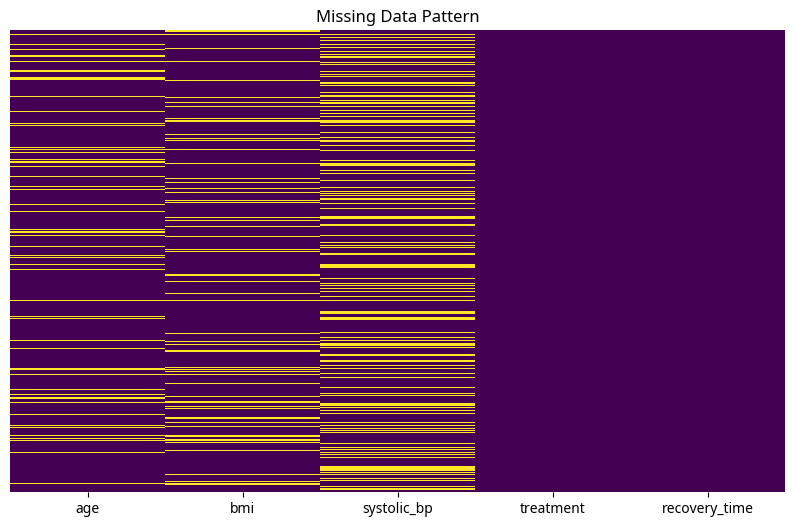

In [2]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_missing.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Pattern')
plt.show()

---

## 4. Handling Missing Data: Methods

### 4.1 Complete Case Analysis (Listwise Deletion)
The paper notes that Complete Case Analysis (CCA) is valid under MCAR. However, it can be biased under MAR or MNAR and always reduces power.

In [3]:
df_cca = df_missing.dropna()
print(f"Original size: {len(df_missing)}, CCA size: {len(df_cca)}")

# Compare means
results = pd.DataFrame({
    'Truth': df_truth.mean(),
    'CCA': df_cca.mean()
})
print("\nMean Comparison:")
print(results)

Original size: 1000, CCA size: 530

Mean Comparison:
                    Truth         CCA
age             55.193321   53.579839
bmi             28.354181   28.111209
systolic_bp    150.338347  148.384629
treatment        0.490000    0.484906
recovery_time   22.394365   22.092502


### 4.2 Single Imputation (Mean Imputation)
Generally discouraged as it underestimates variance and ignores relationships between variables.

In [4]:
imputer = SimpleImputer(strategy='mean')
df_mean_imp = pd.DataFrame(imputer.fit_transform(df_missing), columns=df_missing.columns)

print("\nMean Imputation Results (Age):")
print(f"True Mean: {df_truth['age'].mean():.2f}")
print(f"Mean Imp: {df_mean_imp['age'].mean():.2f}")


Mean Imputation Results (Age):
True Mean: 55.19
Mean Imp: 55.16


### 4.3 Multiple Imputation (Recommended)
Heymans and Twisk strongly recommend Multiple Imputation (MI) for MAR data. MI accounts for the uncertainty of the missing values by creating multiple "filled-in" datasets.

In [5]:
# Using IterativeImputer (MICE-like) for demonstration
# In a real clinical setting, one would use multiple iterations and pool results
mice_imputer = IterativeImputer(max_iter=10, random_state=42)
df_mice = pd.DataFrame(mice_imputer.fit_transform(df_missing), columns=df_missing.columns)

print("\nMI (MICE) Comparison:")
results['MICE'] = df_mice.mean()
print(results)


MI (MICE) Comparison:
                    Truth         CCA        MICE
age             55.193321   53.579839   55.132243
bmi             28.354181   28.111209   28.438091
systolic_bp    150.338347  148.384629  149.464347
treatment        0.490000    0.484906    0.490000
recovery_time   22.394365   22.092502   22.394365


---

## 5. Visualization of Imputation Quality
A good imputation should preserve the distribution of the data.

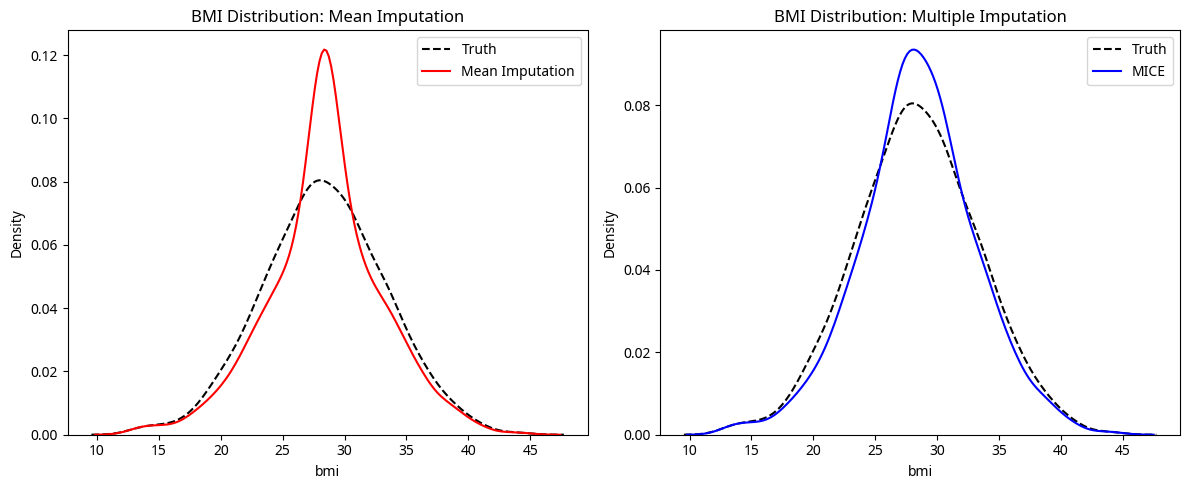

In [6]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.kdeplot(df_truth['bmi'], label='Truth', color='black', linestyle='--')
sns.kdeplot(df_mean_imp['bmi'], label='Mean Imputation', color='red')
plt.title('BMI Distribution: Mean Imputation')
plt.legend()

plt.subplot(1, 2, 2)
sns.kdeplot(df_truth['bmi'], label='Truth', color='black', linestyle='--')
sns.kdeplot(df_mice['bmi'], label='MICE', color='blue')
plt.title('BMI Distribution: Multiple Imputation')
plt.legend()

plt.tight_layout()
plt.show()

---

## 6. Conclusion
As emphasized by Heymans and Twisk:
*   **Preventing missing data** is always better than treating it.
*   **Multiple Imputation** is the preferred method for MAR data.
*   **MNAR** remains a challenge, as MAR and MNAR are often indistinguishable from the data alone.